# Used Car Listings Analysis

## Introduction

This notebook analyzes a used car listings dataset to better understand the factors that influence vehicle resale value. The project focuses on exploring how attributes such as brand, mileage, vehicle age, fuel type, transmission, and condition affect the price of used cars.

This notebook was created and developed using Google Colab. Google Colab allows the analysis to be completed in a cloud-based Python environment without needing to install software locally.

The notebook begins with data cleaning to prepare the dataset for analysis. This includes checking for missing values, removing duplicate records, standardizing column names, and creating new variables such as vehicle age and value retention score. After cleaning the data, the notebook explores key questions about used car depreciation and resale value.

The main questions explored in this notebook are:

1. Which car brands retain their value the best?
2. How does mileage affect used car price?
3. How does vehicle age contribute to depreciation?
4. Do fuel type, transmission, or condition impact resale value?

In addition to data analysis, this notebook includes a machine learning model that predicts used car prices based on vehicle features. The model uses attributes such as brand, year, mileage, fuel type, transmission, condition, body type, and seller type to estimate resale price.

By combining data cleaning, exploratory data analysis, visualization, and machine learning, this project provides useful insights for buyers, sellers, and dealerships in the used car market.|

# Importing Libaries and Datasets



In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/used_car_listings.csv")

# Preview data
df.head()

,listing_id,vin,make,model,year,trim,body_type,fuel_type,transmission,mileage,price,condition,location,seller_type,features
0,1,9M6LF68V634LY2252,Tesla,Model 3,2019,NaN,Coupe,Electric,Manual,46134,19919.0,good,"New Lindsey, GA, US",Dealer,"Alloy Wheels, Android Auto, Apple CarPlay, Fog..."
1,2,1S0ZCY536BSCY2864,Nissan,Rogue,2024,LT,Sedan,Hybrid,Automatic,16109,19480.0,good,"Pughtown, CO, US",Dealer,"Alloy Wheels, Android Auto, Lane Keep Assist, ..."
2,3,YFB625BN0RTMZ5590,Hyundai,i20,2018,XLE,Crossover,Petrol,Automatic,173239,4556.0,good,"Satna, HR, India",Dealer,"Alloy Wheels, Bluetooth, Panoramic Roof, Sunroof"
3,4,CPMZ4RFN5WYL37096,Kia,Sportage,2023,EX,Hatchback,Diesel,CVT,36810,11536.0,fair,"山武市, Osaka, Japan",Certified Pre-Owned,"Alloy Wheels, Bluetooth, Keyless Entry, Naviga..."
4,5,4PJZG3MV6D9365673,Kia,Seltos,2020,Trend,Pickup,Diesel,Automatic,87749,14098.0,good,"長生郡長生村, Osaka, Japan",Certified Pre-Owned,"Apple CarPlay, Backup Camera, Bluetooth, Heate..."


##Check dataset size

In [ ]:
df.shape

(2068, 15)

## Check column names and data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   listing_id    2068 non-null   int64  
 1   vin           2068 non-null   object 
 2   make          2068 non-null   object 
 3   model         2068 non-null   object 
 4   year          2068 non-null   int64  
 5   trim          1824 non-null   object 
 6   body_type     2068 non-null   object 
 7   fuel_type     2068 non-null   object 
 8   transmission  2068 non-null   object 
 9   mileage       2068 non-null   int64  
 10  price         2068 non-null   float64
 11  condition     2022 non-null   object 
 12  location      2068 non-null   object 
 13  seller_type   2068 non-null   object 
 14  features      1917 non-null   object 
dtypes: float64(1), int64(3), object(11)
memory usage: 242.5+ KB


##Summary statistics


In [ ]:
df.describe()

,listing_id,year,mileage,price
count,2068.000000,2068.000000,2068.000000,2068.000000
mean,1034.500000,2016.975822,115626.364603,9182.621857
std,597.124498,4.610981,80971.112603,9964.093618
min,1.000000,2005.000000,0.000000,1140.000000
25%,517.750000,2014.000000,57683.250000,2323.750000
50%,1034.500000,2017.000000,99212.000000,5448.500000
75%,1551.250000,2020.000000,159291.500000,11946.750000
max,2068.000000,2025.000000,418428.000000,72641.000000


## Check missing values

In [ ]:
df.isnull().sum()

,0
listing_id,0
vin,0
make,0
model,0
year,0
trim,244
body_type,0
fuel_type,0
transmission,0
mileage,0


# Data Cleaning

In [ ]:
# Make a copy of the original dataset
df_cleaned = df.copy()

# Standardize column names
df_cleaned.columns = (
    df_cleaned.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_cleaned.head()

,listing_id,vin,make,model,year,trim,body_type,fuel_type,transmission,mileage,price,condition,location,seller_type,features
0,1,9M6LF68V634LY2252,Tesla,Model 3,2019,NaN,Coupe,Electric,Manual,46134,19919.0,good,"New Lindsey, GA, US",Dealer,"Alloy Wheels, Android Auto, Apple CarPlay, Fog..."
1,2,1S0ZCY536BSCY2864,Nissan,Rogue,2024,LT,Sedan,Hybrid,Automatic,16109,19480.0,good,"Pughtown, CO, US",Dealer,"Alloy Wheels, Android Auto, Lane Keep Assist, ..."
2,3,YFB625BN0RTMZ5590,Hyundai,i20,2018,XLE,Crossover,Petrol,Automatic,173239,4556.0,good,"Satna, HR, India",Dealer,"Alloy Wheels, Bluetooth, Panoramic Roof, Sunroof"
3,4,CPMZ4RFN5WYL37096,Kia,Sportage,2023,EX,Hatchback,Diesel,CVT,36810,11536.0,fair,"山武市, Osaka, Japan",Certified Pre-Owned,"Alloy Wheels, Bluetooth, Keyless Entry, Naviga..."
4,5,4PJZG3MV6D9365673,Kia,Seltos,2020,Trend,Pickup,Diesel,Automatic,87749,14098.0,good,"長生郡長生村, Osaka, Japan",Certified Pre-Owned,"Apple CarPlay, Backup Camera, Bluetooth, Heate..."


In [ ]:
# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Check new shape
df_cleaned.shape

(2068, 15)

In [ ]:
# Check missing values again
df_cleaned.isnull().sum()

,0
listing_id,0
vin,0
make,0
model,0
year,0
trim,244
body_type,0
fuel_type,0
transmission,0
mileage,0


In [ ]:
# Fill missing text values with "Unknown"
text_columns = df_cleaned.select_dtypes(include="object").columns

df_cleaned[text_columns] = df_cleaned[text_columns].fillna("Unknown")

# Fill missing numeric values with median
numeric_columns = df_cleaned.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

df_cleaned.isnull().sum()

,0
listing_id,0
vin,0
make,0
model,0
year,0
trim,0
body_type,0
fuel_type,0
transmission,0
mileage,0


In [ ]:
# Remove invalid prices and mileage values
df_cleaned = df_cleaned[df_cleaned["price"] > 0]
df_cleaned = df_cleaned[df_cleaned["mileage"] >= 0]

df_cleaned.shape

(2068, 15)

In [ ]:
# Create vehicle age column
current_year = 2026

df_cleaned["vehicle_age"] = current_year - df_cleaned["year"]

# Remove invalid ages
df_cleaned = df_cleaned[df_cleaned["vehicle_age"] >= 0]

df_cleaned[["year", "vehicle_age"]].head()

,year,vehicle_age
0,2019,7
1,2024,2
2,2018,8
3,2023,3
4,2020,6


In [ ]:
# Create price per mile column
df_cleaned["price_per_mile"] = df_cleaned["price"] / (df_cleaned["mileage"] + 1)

df_cleaned[["price", "mileage", "price_per_mile"]].head()

,price,mileage,price_per_mile
0,19919.0,46134,0.431755
1,19480.0,16109,1.209187
2,4556.0,173239,0.026299
3,11536.0,36810,0.313385
4,14098.0,87749,0.160661


In [ ]:
# Create value retention score
# Higher score means the car keeps a higher price compared to age and mileage

df_cleaned["value_retention_score"] = df_cleaned["price"] / (
    (df_cleaned["vehicle_age"] + 1) * (df_cleaned["mileage"] + 1)
)

df_cleaned[["make", "model", "price", "vehicle_age", "mileage", "value_retention_score"]].head()

,make,model,price,vehicle_age,mileage,value_retention_score
0,Tesla,Model 3,19919.0,7,46134,0.053969
1,Nissan,Rogue,19480.0,2,16109,0.403062
2,Hyundai,i20,4556.0,8,173239,0.002922
3,Kia,Sportage,11536.0,3,36810,0.078346
4,Kia,Seltos,14098.0,6,87749,0.022952


In [ ]:
# Final check after cleaning
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   listing_id             2068 non-null   int64  
 1   vin                    2068 non-null   object 
 2   make                   2068 non-null   object 
 3   model                  2068 non-null   object 
 4   year                   2068 non-null   int64  
 5   trim                   2068 non-null   object 
 6   body_type              2068 non-null   object 
 7   fuel_type              2068 non-null   object 
 8   transmission           2068 non-null   object 
 9   mileage                2068 non-null   int64  
 10  price                  2068 non-null   float64
 11  condition              2068 non-null   object 
 12  location               2068 non-null   object 
 13  seller_type            2068 non-null   object 
 14  features               2068 non-null   object 
 15  vehi

# Data Analysis / Hypothesis Questions

## Question 1: Which car brands retain their value the best?

In [ ]:
brand_value = (
    df_cleaned
    .groupby("make")
    .agg(
        average_price=("price", "mean"),
        average_mileage=("mileage", "mean"),
        average_age=("vehicle_age", "mean"),
        average_value_retention=("value_retention_score", "mean"),
        total_listings=("make", "count")
    )
    .reset_index()
)

# Only include brands with at least 10 listings
brand_value = brand_value[brand_value["total_listings"] >= 10]

# Sort by value retention
brand_value = brand_value.sort_values(by="average_value_retention", ascending=False)

brand_value.head(10)

,make,average_price,average_mileage,average_age,average_value_retention,total_listings
14,Toyota,9744.577586,114059.517241,8.922414,1305.817303,116
1,BMW,13460.424000,112494.344000,8.912000,1146.973947,125
0,Audi,12300.725352,119479.373239,9.338028,951.239637,142
15,Volkswagen,9568.975610,99672.219512,8.455285,937.014732,123
4,Honda,8849.945312,119324.585938,9.125000,807.303218,128
6,Kia,8443.601504,117967.706767,9.082707,779.299478,133
5,Hyundai,9061.943548,106655.395161,8.387097,727.738044,124
12,Tata,6242.936508,104854.150794,8.500000,676.070585,126
2,Chevrolet,8337.525926,124043.918519,9.288889,632.528465,135
13,Tesla,12606.914530,112533.692308,9.247863,620.650133,117


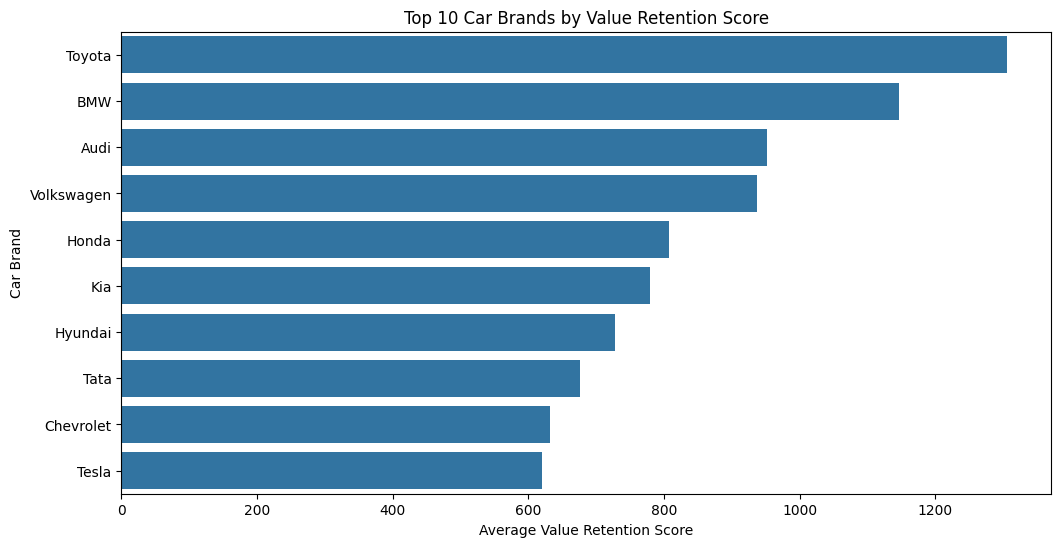

In [ ]:
plt.figure(figsize=(12, 6))

top_brands = brand_value.head(10)

sns.barplot(
    data=top_brands,
    x="average_value_retention",
    y="make"
)

plt.title("Top 10 Car Brands by Value Retention Score")
plt.xlabel("Average Value Retention Score")
plt.ylabel("Car Brand")
plt.show()

## Question 2: How does mileage affect used car price?

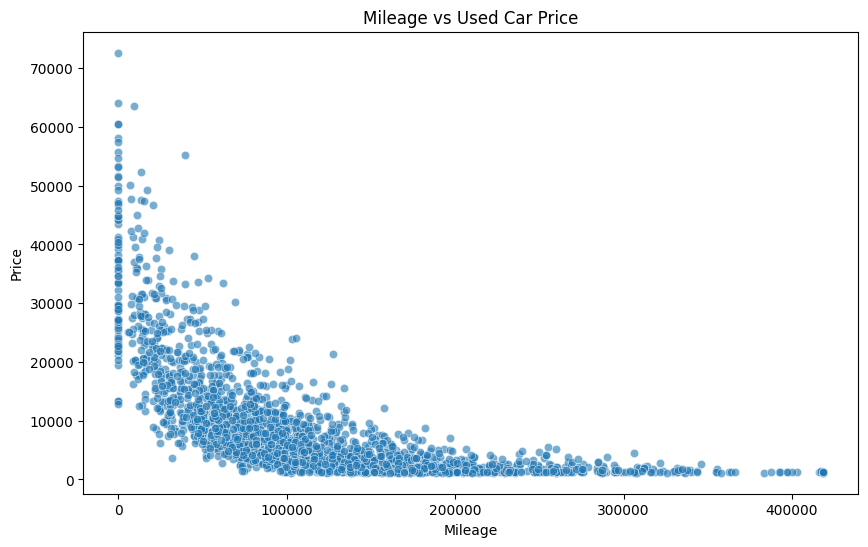

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_cleaned,
    x="mileage",
    y="price",
    alpha=0.6
)

plt.title("Mileage vs Used Car Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

In [ ]:
# Correlation between mileage and price
mileage_price_corr = df_cleaned["mileage"].corr(df_cleaned["price"])

print("Correlation between mileage and price:", mileage_price_corr)

Correlation between mileage and price: -0.6426014288453644


In [ ]:
# Group mileage into ranges
df_cleaned["mileage_group"] = pd.cut(
    df_cleaned["mileage"],
    bins=[0, 25000, 50000, 75000, 100000, 150000, 300000],
    labels=[
        "0-25k",
        "25k-50k",
        "50k-75k",
        "75k-100k",
        "100k-150k",
        "150k+"
    ],
    include_lowest=True
)

mileage_analysis = (
    df_cleaned
    .groupby("mileage_group", observed=True)
    .agg(
        average_price=("price", "mean"),
        total_listings=("price", "count")
    )
    .reset_index()
)

mileage_analysis

,mileage_group,average_price,total_listings
0,0-25k,29435.747706,218
1,25k-50k,16264.500000,220
2,50k-75k,10796.277193,285
3,75k-100k,7790.575851,323
4,100k-150k,4676.909931,433
5,150k+,2449.778846,520


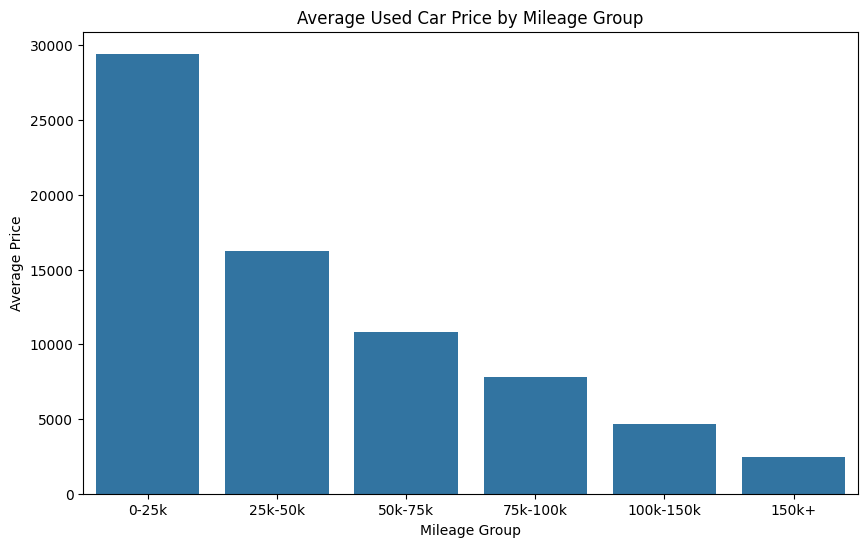

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=mileage_analysis,
    x="mileage_group",
    y="average_price"
)

plt.title("Average Used Car Price by Mileage Group")
plt.xlabel("Mileage Group")
plt.ylabel("Average Price")
plt.show()

## Question 3: How does vehicle age contribute to depreciation?

In [ ]:
age_analysis = (
    df_cleaned
    .groupby("vehicle_age")
    .agg(
        average_price=("price", "mean"),
        total_listings=("price", "count")
    )
    .reset_index()
)

age_analysis.head()

,vehicle_age,average_price,total_listings
0,1,35651.177215,79
1,2,27980.911111,90
2,3,20694.554348,92
3,4,17764.255814,86
4,5,15171.888199,161


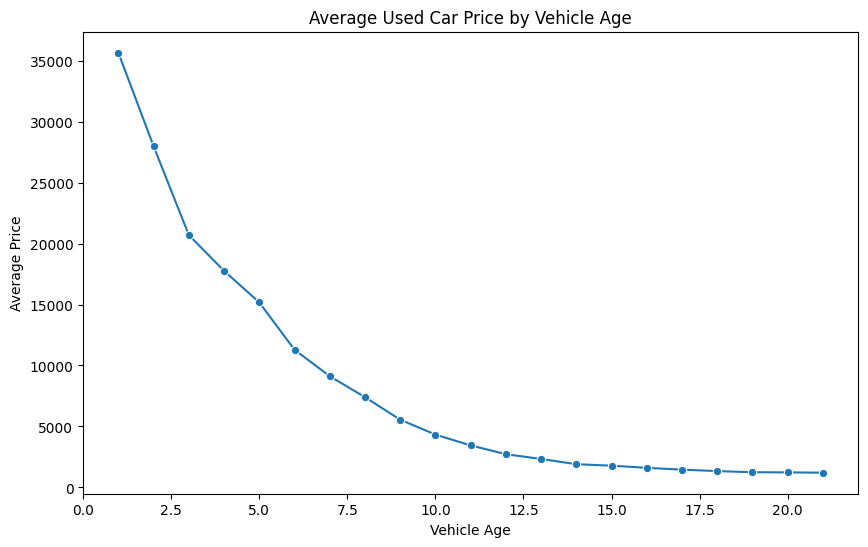

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_analysis,
    x="vehicle_age",
    y="average_price",
    marker="o"
)

plt.title("Average Used Car Price by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Average Price")
plt.show()

In [ ]:
# Correlation between vehicle age and price
age_price_corr = df_cleaned["vehicle_age"].corr(df_cleaned["price"])

print("Correlation between vehicle age and price:", age_price_corr)

Correlation between vehicle age and price: -0.7506339158857854


## Question 4: Do fuel type, transmission, or condition impact resale value?

In [ ]:
fuel_analysis = (
    df_cleaned
    .groupby("fuel_type")
    .agg(
        average_price=("price", "mean"),
        average_value_retention=("value_retention_score", "mean"),
        total_listings=("price", "count")
    )
    .reset_index()
    .sort_values(by="average_price", ascending=False)
)

fuel_analysis

,fuel_type,average_price,average_value_retention,total_listings
2,Electric,11092.555556,878.562926,225
5,Plug-in Hybrid,11088.175258,1094.535561,97
4,Petrol,9445.824236,740.351366,916
1,Diesel,8425.034398,506.905719,407
3,Hybrid,8239.704626,600.468266,281
0,CNG,7194.105634,361.174883,142


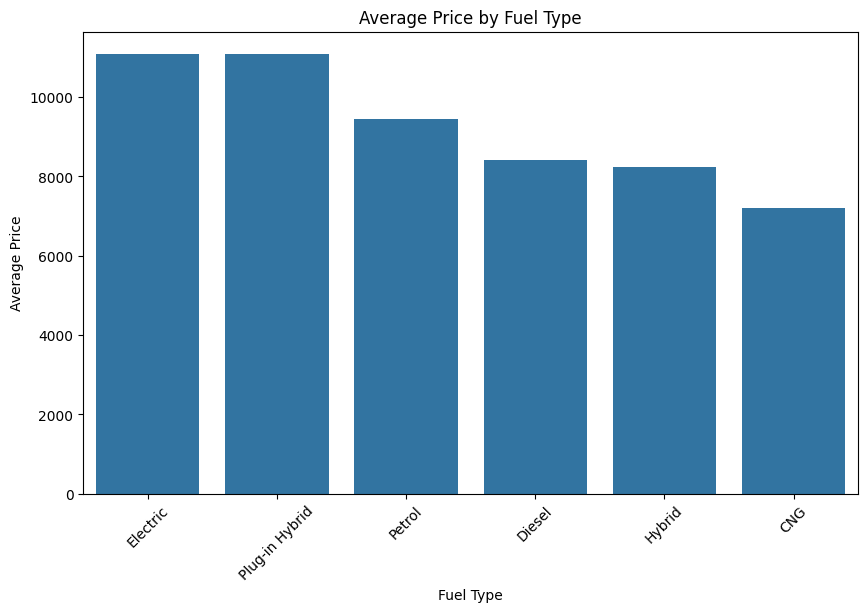

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=fuel_analysis,
    x="fuel_type",
    y="average_price"
)

plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [ ]:
transmission_analysis = (
    df_cleaned
    .groupby("transmission")
    .agg(
        average_price=("price", "mean"),
        average_value_retention=("value_retention_score", "mean"),
        total_listings=("price", "count")
    )
    .reset_index()
    .sort_values(by="average_price", ascending=False)
)

transmission_analysis

,transmission,average_price,average_value_retention,total_listings
1,Automatic,9440.691614,649.928226,1109
4,Manual,9062.900787,735.379853,635
3,DCT,8790.737705,383.027276,61
2,CVT,8705.425234,867.203317,214
0,AMT,7465.244898,237.851410,49


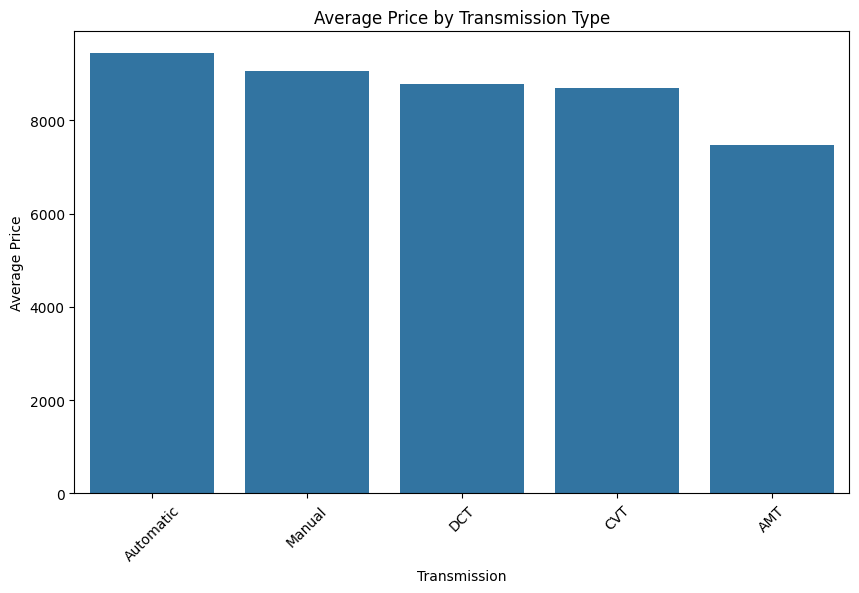

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=transmission_analysis,
    x="transmission",
    y="average_price"
)

plt.title("Average Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [ ]:
condition_analysis = (
    df_cleaned
    .groupby("condition")
    .agg(
        average_price=("price", "mean"),
        average_value_retention=("value_retention_score", "mean"),
        total_listings=("price", "count")
    )
    .reset_index()
    .sort_values(by="average_price", ascending=False)
)

condition_analysis

,condition,average_price,average_value_retention,total_listings
5,new,12359.418605,1038.879682,43
0,Unknown,11513.978261,436.050372,46
4,like new,11201.420000,620.737389,100
1,excellent,10323.159278,878.423255,609
3,good,8561.178922,595.309381,816
2,fair,8294.102493,654.382892,361
6,salvage,5822.849462,264.184726,93


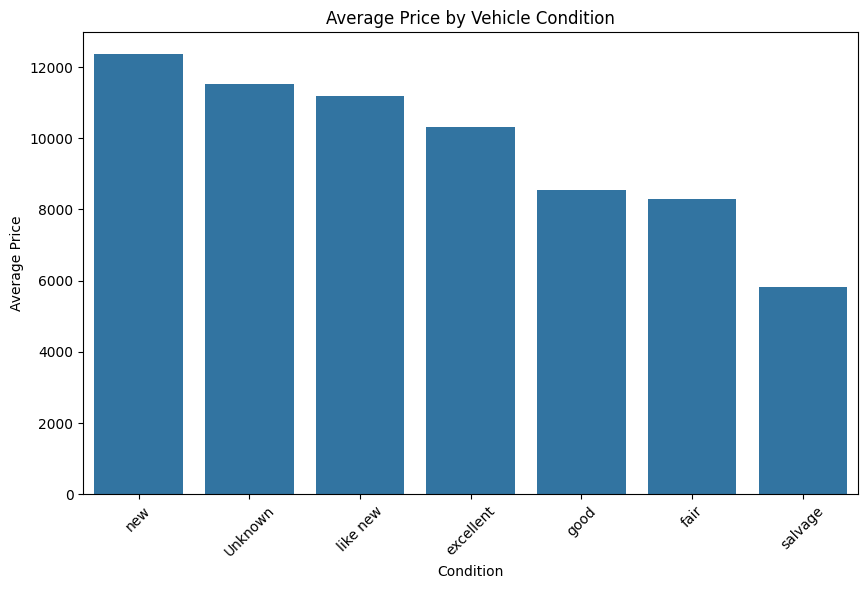

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=condition_analysis,
    x="condition",
    y="average_price"
)

plt.title("Average Price by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

 ## Final Results

In [ ]:
print("Top Brands by Value Retention:")
display(brand_value.head(10))

print("Mileage Analysis:")
display(mileage_analysis)

print("Vehicle Age Analysis:")
display(age_analysis.head(10))

print("Fuel Type Analysis:")
display(fuel_analysis)

print("Transmission Analysis:")
display(transmission_analysis)

print("Condition Analysis:")
display(condition_analysis)


Top Brands by Value Retention:


,make,average_price,average_mileage,average_age,average_value_retention,total_listings
14,Toyota,9744.577586,114059.517241,8.922414,1305.817303,116
1,BMW,13460.424000,112494.344000,8.912000,1146.973947,125
0,Audi,12300.725352,119479.373239,9.338028,951.239637,142
15,Volkswagen,9568.975610,99672.219512,8.455285,937.014732,123
4,Honda,8849.945312,119324.585938,9.125000,807.303218,128
6,Kia,8443.601504,117967.706767,9.082707,779.299478,133
5,Hyundai,9061.943548,106655.395161,8.387097,727.738044,124
12,Tata,6242.936508,104854.150794,8.500000,676.070585,126
2,Chevrolet,8337.525926,124043.918519,9.288889,632.528465,135
13,Tesla,12606.914530,112533.692308,9.247863,620.650133,117


Mileage Analysis:


,mileage_group,average_price,total_listings
0,0-25k,29435.747706,218
1,25k-50k,16264.500000,220
2,50k-75k,10796.277193,285
3,75k-100k,7790.575851,323
4,100k-150k,4676.909931,433
5,150k+,2449.778846,520


Vehicle Age Analysis:


...

,fuel_type,average_price,average_value_retention,total_listings
2,Electric,11092.555556,878.562926,225
5,Plug-in Hybrid,11088.175258,1094.535561,97
4,Petrol,9445.824236,740.351366,916
1,Diesel,8425.034398,506.905719,407
3,Hybrid,8239.704626,600.468266,281
0,CNG,7194.105634,361.174883,142


Transmission Analysis:


,transmission,average_price,average_value_retention,total_listings
1,Automatic,9440.691614,649.928226,1109
4,Manual,9062.900787,735.379853,635
3,DCT,8790.737705,383.027276,61
2,CVT,8705.425234,867.203317,214
0,AMT,7465.244898,237.851410,49


Condition Analysis:


,condition,average_price,average_value_retention,total_listings
5,new,12359.418605,1038.879682,43
0,Unknown,11513.978261,436.050372,46
4,like new,11201.420000,620.737389,100
1,excellent,10323.159278,878.423255,609
3,good,8561.178922,595.309381,816
2,fair,8294.102493,654.382892,361
6,salvage,5822.849462,264.184726,93


# Machine Learning: Predicting Used Car Prices

In [ ]:
# Select features for the model

features = [
    "make",
    "model",
    "year",
    "body_type",
    "fuel_type",
    "transmission",
    "mileage",
    "condition",
    "seller_type",
    "vehicle_age"
]

target = "price"

# Create model dataframe
ml_df = df_cleaned[features + [target]].copy()

ml_df.head()

,make,model,year,body_type,fuel_type,transmission,mileage,condition,seller_type,vehicle_age,price
0,Tesla,Model 3,2019,Coupe,Electric,Manual,46134,good,Dealer,7,19919.0
1,Nissan,Rogue,2024,Sedan,Hybrid,Automatic,16109,good,Dealer,2,19480.0
2,Hyundai,i20,2018,Crossover,Petrol,Automatic,173239,good,Dealer,8,4556.0
3,Kia,Sportage,2023,Hatchback,Diesel,CVT,36810,fair,Certified Pre-Owned,3,11536.0
4,Kia,Seltos,2020,Pickup,Diesel,Automatic,87749,good,Certified Pre-Owned,6,14098.0


In [ ]:
# Check missing values before modeling
ml_df.isnull().sum()

,0
make,0
model,0
year,0
body_type,0
fuel_type,0
transmission,0
mileage,0
condition,0
seller_type,0
vehicle_age,0


In [ ]:
# Drop missing values for machine learning
ml_df = ml_df.dropna()

ml_df.shape

(2068, 11)

In [ ]:
# Separate features and target variable

X = ml_df[features]
y = ml_df[target]

X.head()

,make,model,year,body_type,fuel_type,transmission,mileage,condition,seller_type,vehicle_age
0,Tesla,Model 3,2019,Coupe,Electric,Manual,46134,good,Dealer,7
1,Nissan,Rogue,2024,Sedan,Hybrid,Automatic,16109,good,Dealer,2
2,Hyundai,i20,2018,Crossover,Petrol,Automatic,173239,good,Dealer,8
3,Kia,Sportage,2023,Hatchback,Diesel,CVT,36810,fair,Certified Pre-Owned,3
4,Kia,Seltos,2020,Pickup,Diesel,Automatic,87749,good,Certified Pre-Owned,6


In [ ]:
# Identify categorical and numerical columns

categorical_features = [
    "make",
    "model",
    "body_type",
    "fuel_type",
    "transmission",
    "condition",
    "seller_type"
]

numerical_features = [
    "year",
    "mileage",
    "vehicle_age"
]

In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1654, 10)
Testing set size: (414, 10)


In [ ]:
# Preprocessing step
# OneHotEncoder converts text categories into numeric columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

## Model 1: Linear Regression

In [ ]:
# Create Linear Regression model pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['make', 'model', 'body_type',
                                                   'fuel_type', 'transmission',
                                                   'condition',
                                                   'seller_type']),
                                                 ('num', 'passthrough',
                                                  ['year', 'mileage',
                                                   'vehicle_age'])])),
                ('model', LinearRegression())])

In [ ]:
# Make predictions

linear_predictions = linear_model.predict(X_test)

# Evaluate model
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("Mean Absolute Error:", linear_mae)
print("Root Mean Squared Error:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
Mean Absolute Error: 4087.3477387758708
Root Mean Squared Error: 5733.150081424235
R² Score: 0.6559046540675171


## Model 2: Random Forest Regressor

In [ ]:
# Create Random Forest model pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['make', 'model', 'body_type',
                                                   'fuel_type', 'transmission',
                                                   'condition',
                                                   'seller_type']),
                                                 ('num', 'passthrough',
                                                  ['year', 'mileage',
                                                   'vehicle_age'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
# Make predictions

rf_predictions = random_forest_model.predict(X_test)

# Evaluate model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("Mean Absolute Error:", rf_mae)
print("Root Mean Squared Error:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
Mean Absolute Error: 1807.5963285024152
Root Mean Squared Error: 3257.819166751825
R² Score: 0.8888917966210997


## Compare Machine Learning Models

In [ ]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Mean Absolute Error": [linear_mae, rf_mae],
    "Root Mean Squared Error": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_results

,Model,Mean Absolute Error,Root Mean Squared Error,R2 Score
0,Linear Regression,4087.347739,5733.150081,0.655905
1,Random Forest,1807.596329,3257.819167,0.888892


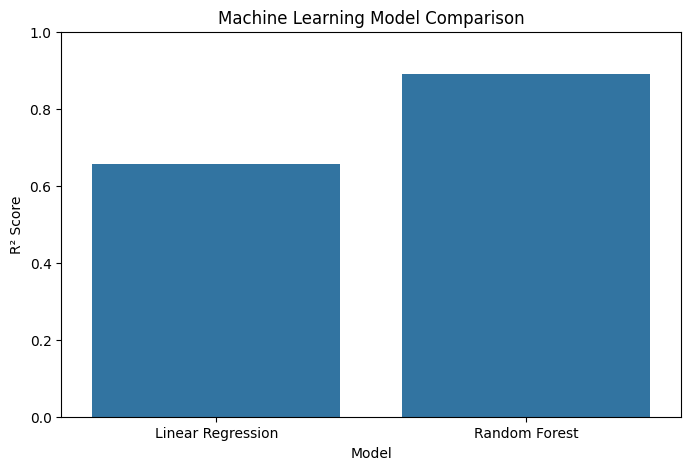

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2 Score"
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

## Actual Price vs Predicted Price

In [ ]:
prediction_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": rf_predictions
})

prediction_results.head(10)

,Actual Price,Predicted Price
1956,3943.0,3911.06
69,13468.0,16895.70
1568,12079.0,14929.68
1630,8884.0,7428.84
2060,4374.0,4581.31
777,16486.0,11716.59
976,1314.0,1287.92
1605,1191.0,1389.10
436,9542.0,14797.02
1278,12620.0,7948.46


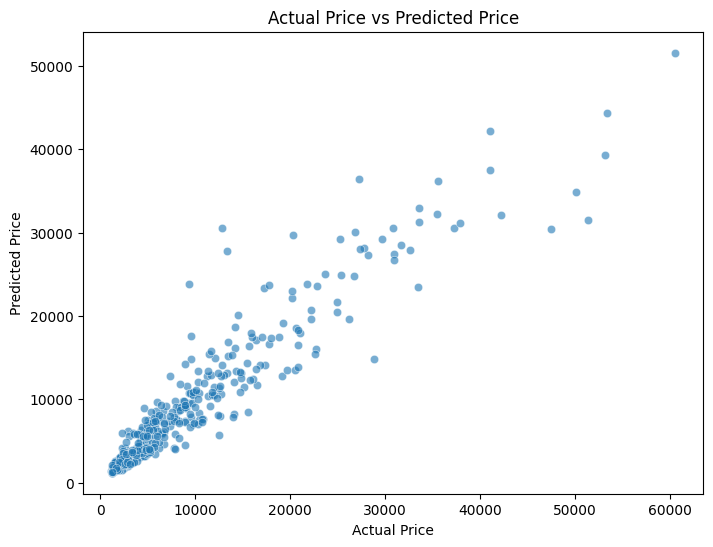

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=prediction_results,
    x="Actual Price",
    y="Predicted Price",
    alpha=0.6
)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## Machine Learning Model

For the machine learning portion of this project, the goal is to predict the price of a used car based on its features. The target variable is `price`, and the input features include brand, model, year, mileage, body type, fuel type, transmission, condition, seller type, and vehicle age.

Two regression models are used:

1. Linear Regression
2. Random Forest Regressor

Linear Regression provides a simple baseline model, while Random Forest is a more advanced model that can capture more complex relationships in the data.

The models are evaluated using:

- Mean Absolute Error
- Root Mean Squared Error
- R² Score

The R² score shows how well the model explains price variation. A higher R² score means the model performs better.

# Conclusion

This notebook analyzed a used car listings dataset to better understand the factors that influence resale value. The analysis focused on brand, mileage, vehicle age, fuel type, transmission, and condition.

The data cleaning process prepared the dataset by removing duplicates, handling missing values, standardizing column names, and creating new columns such as vehicle age and value retention score.

The exploratory analysis showed how mileage and vehicle age are related to used car prices. In general, vehicles with higher mileage and older model years tend to have lower resale prices. The analysis also compared average prices across fuel types, transmission types, and vehicle conditions.

The machine learning section added a predictive component to the project. Linear Regression and Random Forest models were used to predict used car prices based on vehicle features. The model results help show how well vehicle attributes can estimate resale price.

Overall, this project combines data cleaning, exploratory data analysis, visualization, and machine learning to better understand used car pricing and depreciation.